In [1]:
from google.colab import files
uploaded = files.upload()

Saving Salary_Data_Based_country_and_race.csv to Salary_Data_Based_country_and_race.csv


In [2]:
import pandas as pd

df = pd.read_csv('Salary_Data_Based_country_and_race.csv')

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Gender', 'Education Level', 'Job Title',
       'Years of Experience', 'Salary', 'Country', 'Race'],
      dtype='object')


First 5 Rows:

   Unnamed: 0   Age  Gender Education Level          Job Title  \
0           0  32.0    Male      Bachelor's  Software Engineer   
1           1  28.0  Female        Master's       Data Analyst   
2           2  45.0    Male             PhD     Senior Manager   
3           3  36.0  Female      Bachelor's    Sales Associate   
4           4  52.0    Male        Master's           Director   

   Years of Experience    Salary Country      Race  
0                  5.0   90000.0      UK     White  
1                  3.0   65000.0     USA  Hispanic  
2                 15.0  150000.0  Canada     White  
3                  7.0   60000.0     USA  Hispanic  
4                 20.0  200000.0     USA     Asian  

Dataset Shape:
(6704, 9)

Column Names:
Index(['Unnamed: 0', 'Age', 'Gender', 'Education Level', 'Job Title',
       'Years of Experience', 'Salary', 'Country', 'Race'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries

/tmp/ipykernel_17911/4077142972.py:83: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_17911/4077142972.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr


Data Types:

Unnamed: 0               int64
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
Country                 object
Race                    object
dtype: object

Shape After Outlier Removal:
(6704, 9)

MODEL PERFORMANCE
MAE : 1976.469341222885
MSE : 28959174.275181793
R2 Score : 0.989156656354117

Top 10 Important Features:

                         Feature  Importance
2            Years of Experience    0.722634
0                     Unnamed: 0    0.213737
1                            Age    0.018334
7    Education Level_high school    0.005678
31      Job Title_data scientist    0.005351
29        Job Title_data analyst    0.004616
11           Education Level_phd    0.003393
188  Job Title_software engineer    0.003187
53   Job Title_financial manager    0.002823
118    Job Title_product manager    0.002704

Actual vs Predicted:

      Act

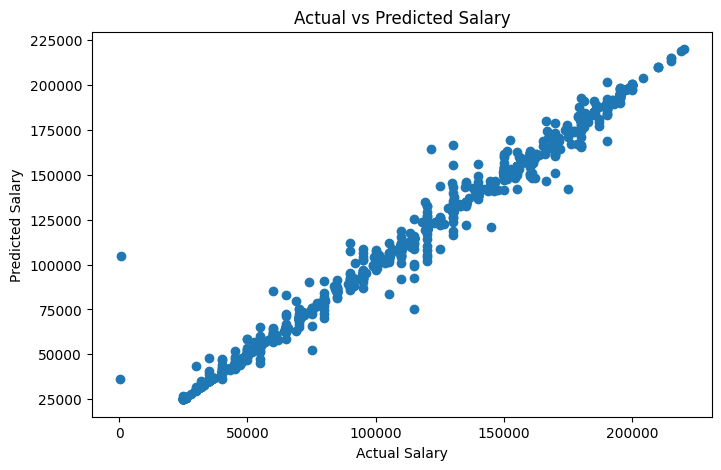


Correlation With Target:

Salary                                 1.000000
Years of Experience                    0.808957
Age                                    0.727983
Education Level_phd                    0.483159
Job Title_software engineer manager    0.264146
Job Title_data scientist               0.259080
Job Title_senior project engineer      0.215265
Education Level_master's               0.169765
Job Title_director of data science     0.156615
Job Title_senior software engineer     0.132603
Name: Salary, dtype: float64


In [6]:
# ==========================================
# EMPLOYEE SALARY PREDICTION PROJECT
# FULL DATA CLEANING + MODEL TRAINING
# ==========================================

# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# LOAD DATASET
# ================================

df = pd.read_csv('Salary_Data_Based_country_and_race.csv')

# ================================
# BASIC DATA INSPECTION
# ================================

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# ================================
# CLEAN COLUMN NAMES
# ================================

df.columns = df.columns.str.strip()

# ================================
# REMOVE DUPLICATES
# ================================

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

# ================================
# REMOVE UNNECESSARY COLUMNS
# ================================

columns_to_drop = [
    'EmployeeID',
    'Employee_ID',
    'ID',
    'Id',
    'Name',
    'Full_Name'
]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# ================================
# CLEAN TEXT DATA
# ================================

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# ================================
# HANDLE MISSING VALUES
# ================================

# Numeric columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ================================
# CHECK DATA TYPES
# ================================

print("\nData Types:\n")
print(df.dtypes)

# ================================
# TARGET COLUMN
# ================================

# Use your actual salary column name
target_column = 'Salary'

# ================================
# REMOVE OUTLIERS
# ================================

Q1 = df[target_column].quantile(0.25)
Q3 = df[target_column].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df[target_column] >= lower) &
    (df[target_column] <= upper)
]

print("\nShape After Outlier Removal:")
print(df.shape)

# ================================
# ENCODE CATEGORICAL VARIABLES
# ================================

df = pd.get_dummies(df, drop_first=True)

# ================================
# FEATURE & TARGET SEPARATION
# ================================

X = df.drop(target_column, axis=1)
y = df[target_column]

# ================================
# TRAIN TEST SPLIT
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ================================
# MODEL TRAINING
# ================================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

# ================================
# PREDICTION
# ================================

y_pred = model.predict(X_test)

# ================================
# MODEL EVALUATION
# ================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

# ================================
# FEATURE IMPORTANCE
# ================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features:\n")
print(importance.head(10))

# ================================
# ACTUAL VS PREDICTED
# ================================

comparison = pd.DataFrame({
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})

print("\nActual vs Predicted:\n")
print(comparison.head(10))

# ================================
# VISUALIZATION
# ================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

# ================================
# CORRELATION WITH TARGET
# ================================

print("\nCorrelation With Target:\n")

print(
    df.corr()[target_column]
    .sort_values(ascending=False)
    .head(10)
)

In [8]:
!pip install xgboost

In [9]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))

MAE: 2427.815056103188
R2 Score: 0.9882935874325858


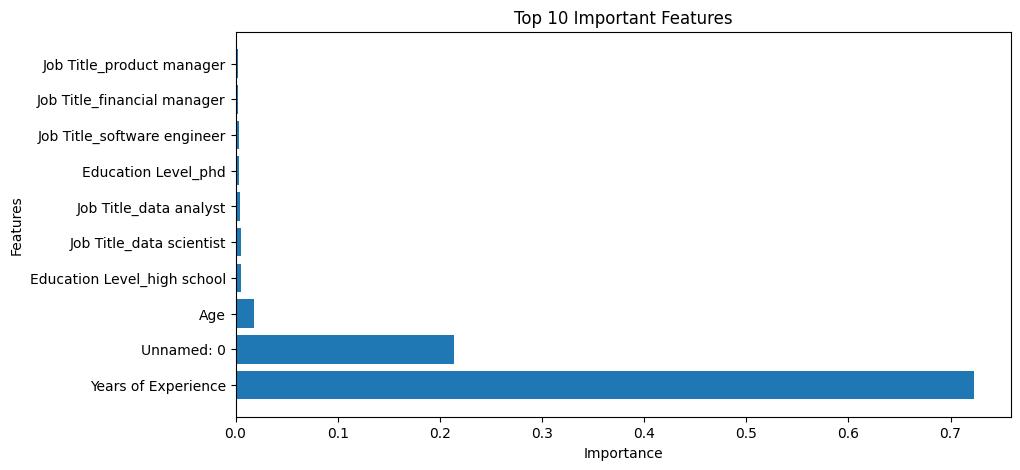

In [10]:
importance = importance.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()